In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report
import warnings

warnings.filterwarnings("ignore")
import joblib


In [3]:
data=pd.read_csv("E:/spaceX/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
data.shape

(7043, 21)

In [6]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
data.duplicated().sum()

0

In [10]:
data['customerID'].duplicated().sum()

0

In [11]:
#no duplicated value as well as null value

In [12]:
for i in data.select_dtypes(include="object"):
    print("\n ",i," = ",data[i].unique())


  customerID  =  ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

  gender  =  ['Female' 'Male']

  Partner  =  ['Yes' 'No']

  Dependents  =  ['No' 'Yes']

  PhoneService  =  ['No' 'Yes']

  MultipleLines  =  ['No phone service' 'No' 'Yes']

  InternetService  =  ['DSL' 'Fiber optic' 'No']

  OnlineSecurity  =  ['No' 'Yes' 'No internet service']

  OnlineBackup  =  ['Yes' 'No' 'No internet service']

  DeviceProtection  =  ['No' 'Yes' 'No internet service']

  TechSupport  =  ['No' 'Yes' 'No internet service']

  StreamingTV  =  ['No' 'Yes' 'No internet service']

  StreamingMovies  =  ['No' 'Yes' 'No internet service']

  Contract  =  ['Month-to-month' 'One year' 'Two year']

  PaperlessBilling  =  ['Yes' 'No']

  PaymentMethod  =  ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

  TotalCharges  =  ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']

  Churn  =  ['No' 'Yes']


In [13]:
# no rare/unusual values

In [14]:
data.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [15]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [16]:
data.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [17]:
data['TotalCharges'].isnull().sum()

11

In [18]:
data[data['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [19]:
data['TotalCharges'] = data['TotalCharges'].fillna(0)

In [20]:
data['TotalCharges'].isnull().sum()

0

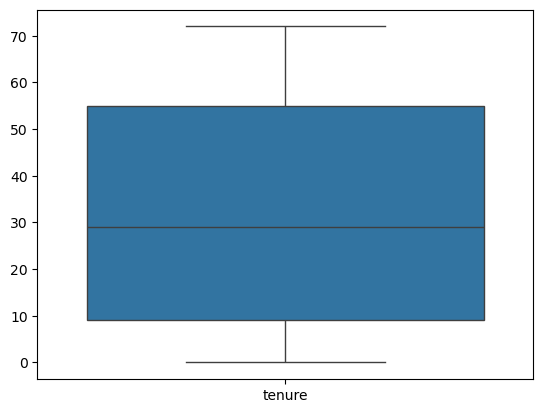

In [21]:
sns.boxplot(data=data[['tenure']])
plt.show()

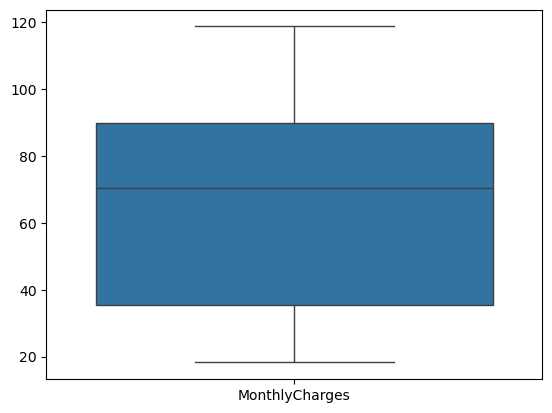

In [22]:
sns.boxplot(data=data[['MonthlyCharges']])
plt.show()

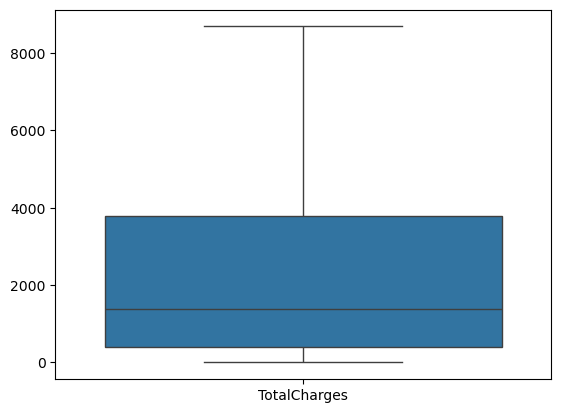

In [23]:
sns.boxplot(data=data[['TotalCharges']])
plt.show()

In [24]:
#no outlires

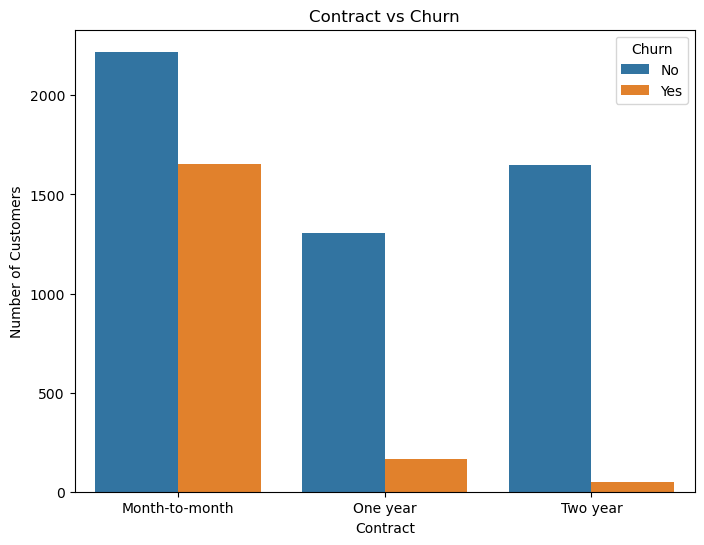

In [25]:
plt.figure(figsize=(8, 6))

sns.countplot(x="Contract", hue="Churn", data=data)

plt.title("Contract vs Churn")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")

plt.savefig("contract_vs_churn.png")

plt.show()

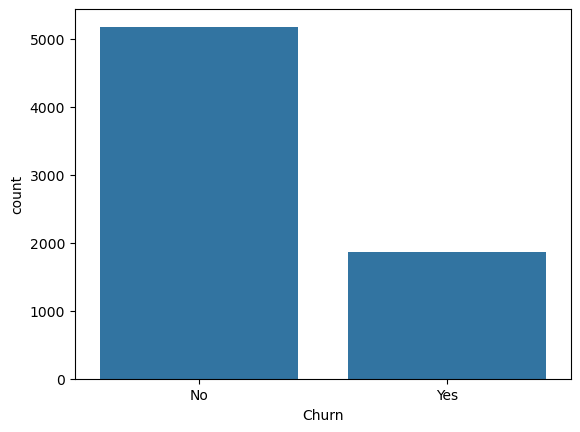

In [26]:
sns.countplot(x='Churn', data=data)
plt.savefig("churn_count.png")
plt.show()


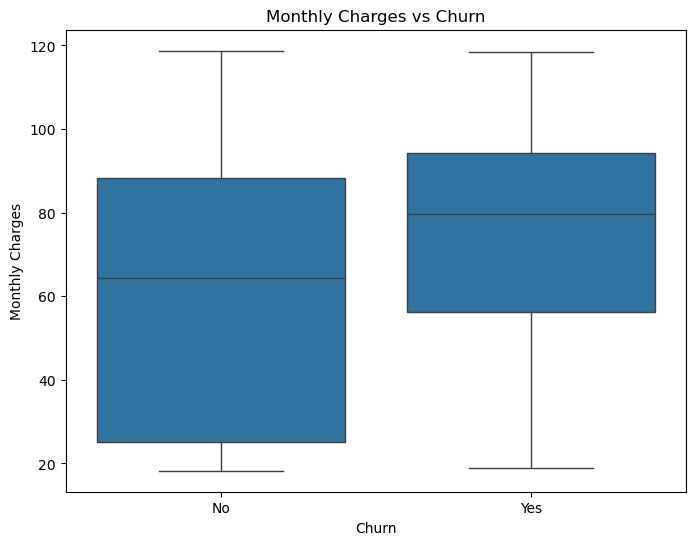

In [27]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=data
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [28]:
cols = data.select_dtypes(include='object').columns.drop(
    ['Churn' ,'customerID','gender','Partner','Dependents','PhoneService']
)

print(cols)

Index(['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [29]:
cols = data.select_dtypes(include='object').columns.drop(
    ['Churn', 'customerID', 'gender', 'Partner', 'Dependents', 'PhoneService']
)

print(cols)

# One-Hot Encoding
data = pd.get_dummies(
    data,
    columns=cols,
    drop_first=True,
    dtype=int
)

data.head()

Index(['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MonthlyCharges,TotalCharges,Churn,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,Female,0,Yes,No,1,No,29.85,29.85,No,...,0,0,0,0,0,0,1,0,1,0
1,5575-GNVDE,Male,0,No,No,34,Yes,56.95,1889.50,No,...,0,0,0,0,1,0,0,0,0,1
2,3668-QPYBK,Male,0,No,No,2,Yes,53.85,108.15,Yes,...,0,0,0,0,0,0,1,0,0,1
3,7795-CFOCW,Male,0,No,No,45,No,42.30,1840.75,No,...,0,0,0,0,1,0,0,0,0,0
4,9237-HQITU,Female,0,No,No,2,Yes,70.70,151.65,Yes,...,0,0,0,0,0,0,1,0,1,0


In [30]:
binary_cols = ['Churn', 'gender', 'Partner', 'Dependents', 'PhoneService']

for col in binary_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])



In [31]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MonthlyCharges,TotalCharges,Churn,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,29.85,29.85,0,...,0,0,0,0,0,0,1,0,1,0
1,5575-GNVDE,1,0,0,0,34,1,56.95,1889.50,0,...,0,0,0,0,1,0,0,0,0,1
2,3668-QPYBK,1,0,0,0,2,1,53.85,108.15,1,...,0,0,0,0,0,0,1,0,0,1
3,7795-CFOCW,1,0,0,0,45,0,42.30,1840.75,0,...,0,0,0,0,1,0,0,0,0,0
4,9237-HQITU,0,0,0,0,2,1,70.70,151.65,1,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,0,1,1,24,1,84.80,1990.50,0,...,0,1,0,1,1,0,1,0,0,1
7039,2234-XADUH,0,0,1,1,72,1,103.20,7362.90,0,...,0,1,0,1,1,0,1,1,0,0
7040,4801-JZAZL,0,0,1,1,11,0,29.60,346.45,0,...,0,0,0,0,0,0,1,0,1,0
7041,8361-LTMKD,1,1,1,0,4,1,74.40,306.60,1,...,0,0,0,0,0,0,1,0,0,1


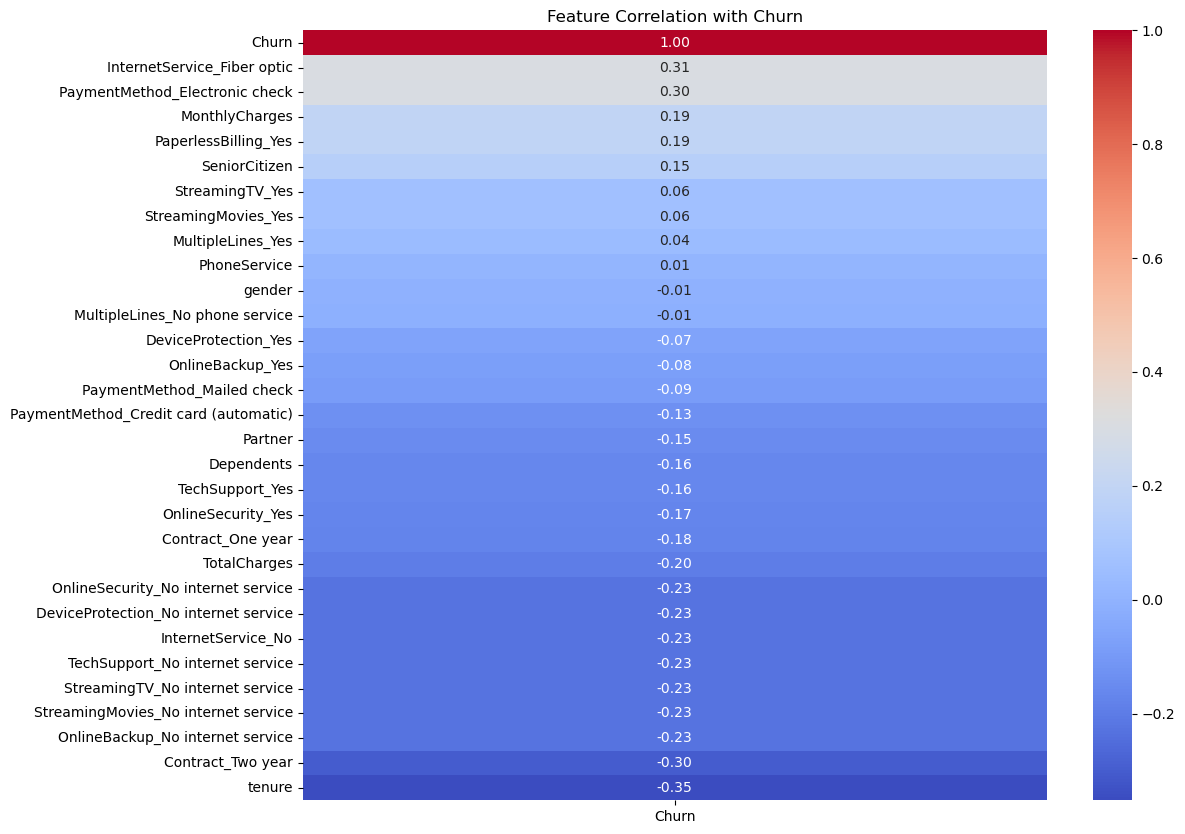

In [32]:
df = data.drop(columns=["customerID"], errors="ignore")

corr = df.corr(numeric_only=True)["Churn"].sort_values(ascending=False)

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr.to_frame(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation with Churn")
plt.savefig("churn_correlation.png")
plt.show()

In [33]:
X = data.drop(columns=['Churn','customerID'])
y = data['Churn']



In [34]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MonthlyCharges,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,29.85,29.85,1,0,...,0,0,0,0,0,0,1,0,1,0
1,1,0,0,0,34,1,56.95,1889.50,0,0,...,0,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,53.85,108.15,0,0,...,0,0,0,0,0,0,1,0,0,1
3,1,0,0,0,45,0,42.30,1840.75,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,2,1,70.70,151.65,0,0,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,84.80,1990.50,0,1,...,0,1,0,1,1,0,1,0,0,1
7039,0,0,1,1,72,1,103.20,7362.90,0,1,...,0,1,0,1,1,0,1,1,0,0
7040,0,0,1,1,11,0,29.60,346.45,1,0,...,0,0,0,0,0,0,1,0,1,0
7041,1,1,1,0,4,1,74.40,306.60,0,1,...,0,0,0,0,0,0,1,0,0,1


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

In [36]:
scale_cols = ['MonthlyCharges', 'TotalCharges']

In [37]:
scaler = StandardScaler()

In [38]:
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

In [39]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MonthlyCharges,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,1,0,0,0,35,0,-0.521976,-0.262257,1,0,...,0,1,0,1,0,0,0,0,1,0
3151,1,0,1,1,15,1,0.337478,-0.503635,0,0,...,0,0,0,0,0,0,0,0,0,1
4860,1,0,1,1,13,0,-0.809013,-0.749883,1,0,...,0,0,0,0,0,1,0,0,0,1
3867,0,0,1,0,26,1,0.284384,-0.172722,0,0,...,0,1,0,1,0,1,1,1,0,0
3810,1,0,1,1,1,1,-0.676279,-0.989374,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6303,0,0,1,0,71,1,1.470695,2.373129,0,1,...,0,1,0,1,0,1,0,0,1,0
6227,1,0,0,0,2,1,-0.626504,-0.973665,0,0,...,0,0,0,0,0,0,0,0,0,0
4673,0,1,0,0,25,1,1.256662,0.158344,0,1,...,0,1,0,1,0,0,1,0,0,1
2710,0,0,1,0,24,1,-1.477661,-0.797075,0,0,...,1,0,1,0,1,0,0,1,0,0


In [40]:
model_logistic = LogisticRegression(
    max_iter=100
)

cv_scores = cross_val_score(
    model_logistic,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("\nCross Validation Scores:")
print(cv_scores)

print("Mean CV Accuracy:",
      cv_scores.mean())


Cross Validation Scores:
[0.83052351 0.80035492 0.80212955 0.79148181 0.79218472]
Mean CV Accuracy: 0.8033349041215064


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

model_random = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

cv_scores = cross_val_score(
    model_random,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("\nCross Validation Scores:")
print(cv_scores)

print("Mean CV Accuracy:", cv_scores.mean())


Cross Validation Scores:
[0.80212955 0.79325643 0.78793256 0.77905945 0.77619893]
Mean CV Accuracy: 0.7877153857913541


In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

model_tree = DecisionTreeClassifier(
    random_state=42
)

cv_scores = cross_val_score(
    model_tree,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("\nDecision Tree Cross Validation Scores:")
print(cv_scores)

print("Mean CV Accuracy:", cv_scores.mean())


Decision Tree Cross Validation Scores:
[0.72404614 0.73380657 0.71872227 0.7284827  0.73090586]
Mean CV Accuracy: 0.7271927073400988


In [43]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n\n================ {name} ================")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report (Accuracy, Precision, Recall, F1):")
    print(classification_report(y_test, y_pred))



================ Logistic Regression ================
Confusion Matrix:
[[927 108]
 [165 209]]

Classification Report (Accuracy, Precision, Recall, F1):
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



================ Decision Tree ================
Confusion Matrix:
[[850 185]
 [189 185]]

Classification Report (Accuracy, Precision, Recall, F1):
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1035
           1       0.50      0.49      0.50       374

    accuracy                           0.73      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.73      0.73      0.73      1409



================ Random Forest =========

In [44]:
# 1. Store the column names from your encoded feature set (X)
model_columns = X.columns.tolist()

# 2. Save all artifacts
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoders.pkl")
joblib.dump(model_columns, "model_columns.pkl")

print("Successfully saved all model files!")

Successfully saved all model files!
